> **Note:** this notebook is the v1 (masterCategory) record, kept as-is as an honest historical artifact. See [03_subcategory_case_study.ipynb](03_subcategory_case_study.ipynb) for the current case study (subCategory target, richer attributes, multi-seed statistical rigor).

# Product Category Classifier — Case Study

**Problem.** A product catalog has photos and a couple of structured attributes (here, the shopper segment a product is tagged for) but no reliable category label. Tagging it by hand doesn't scale. Can a model that sees both the photo *and* that attribute do better than one that only sees the photo?

**Where this came from.** The model architecture below is adapted from a multi-input pattern I first built for a DataCamp AI Engineer certification exercise (an OCR model combining a document image with a categorical "insurance type" field). The architecture transfers almost exactly; the dataset, problem framing, evaluation, and the agent layer on top are new.

This notebook tells the story end to end without retraining anything — it loads the artifacts produced by `src/train.py` and `src/evaluate.py` and walks through what they show. See `01_eda.ipynb` for the exploratory work that drove the modeling decisions below.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.models import BaselineImageModel, MultiModalProductClassifier

ARTIFACTS = ROOT / "artifacts"
metrics = {name: json.loads((ARTIFACTS / f"metrics_{name}.json").read_text()) for name in ("baseline", "proposed")}
class_names = metrics["baseline"]["class_names"]
print("Classes:", class_names)

Classes: ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Personal Care']


## Approach

- **Target:** `masterCategory` (5 classes after dropping two with under 100 samples each — see `01_eda.ipynb`).
- **Second modality:** `gender` (5 categories) — the EDA notebook showed this genuinely correlates with category mix, not just noise.
- **Baseline:** image-only CNN. **Proposed:** the same image branch plus a small `gender_layer` MLP, concatenated before the classifier head — a near 1:1 translation of the original cert exercise's multi-input pattern.
- Both trained identically (80x80 RGB, same split, same 10 epochs, same class-weighted loss) so the only real variable between them is whether the model sees `gender`.

In [2]:
print("Baseline -- image only:\n")
print(BaselineImageModel(num_classes=len(class_names)))
print("\n\nProposed -- image + gender:\n")
print(MultiModalProductClassifier(num_classes=len(class_names), num_genders=5))

Baseline -- image only:

BaselineImageModel(
  (image_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_features=12800, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=5, bias=True)
  )
)


Proposed -- image + gender:

MultiModalProductClassifier(
  (image_layer): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(

## Results

Headline numbers first, then the honest breakdown of where the lift actually comes from.

In [3]:
summary = pd.DataFrame({
    name: {
        "accuracy": metrics[name]["accuracy"],
        "macro_f1": metrics[name]["macro_f1"],
        "weighted_f1": metrics[name]["weighted_f1"],
        "high_confidence_rate (>=0.85)": metrics[name]["high_confidence_rate"],
    }
    for name in ("baseline", "proposed")
}).T
summary.round(4)

,accuracy,macro_f1,weighted_f1,high_confidence_rate (>=0.85)
baseline,0.9593,0.8024,0.9598,0.9257
proposed,0.9569,0.7793,0.9626,0.9105


Accuracy and weighted-F1 are close to a draw (weighted-F1 actually edges toward the proposed model: 0.963 vs 0.960). Macro-F1 favors the baseline -- but that's almost entirely one class dragging it down, as the per-class chart below shows.

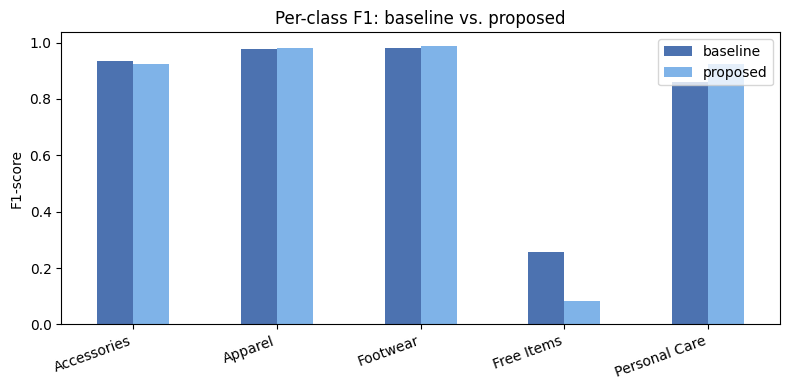

,baseline,proposed
Accessories,0.933,0.922
Apparel,0.978,0.981
Footwear,0.981,0.987
Free Items,0.258,0.081
Personal Care,0.862,0.925


In [4]:
per_class = pd.DataFrame({
    name: {c: metrics[name]["per_class"][c]["f1-score"] for c in class_names}
    for name in ("baseline", "proposed")
})
ax = per_class.plot.bar(figsize=(8, 4), color=["#4C72B0", "#7FB3E8"])
ax.set_ylabel("F1-score")
ax.set_title("Per-class F1: baseline vs. proposed")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()
per_class.round(3)

Two things stand out, and both are more interesting than a flat "ours is better":

1. **Free Items** (16 test examples, ~105 total in the whole dataset) is unreliable for *both* models -- that's a data scarcity problem, not an architecture problem. It's also most of why macro-F1 favors the baseline: macro-F1 weights every class equally regardless of how few examples back it up.
2. **Personal Care** is the real, attributable win for the proposed model (F1 0.925 vs. 0.862), driven by a large precision improvement (0.93 vs 0.76 -- far fewer false positives). This is exactly the class the EDA notebook's gender x masterCategory crosstab flagged as having a real relationship with gender. The multi-modal branch earns its keep specifically where the data says it should -- not everywhere, which is the honest result.

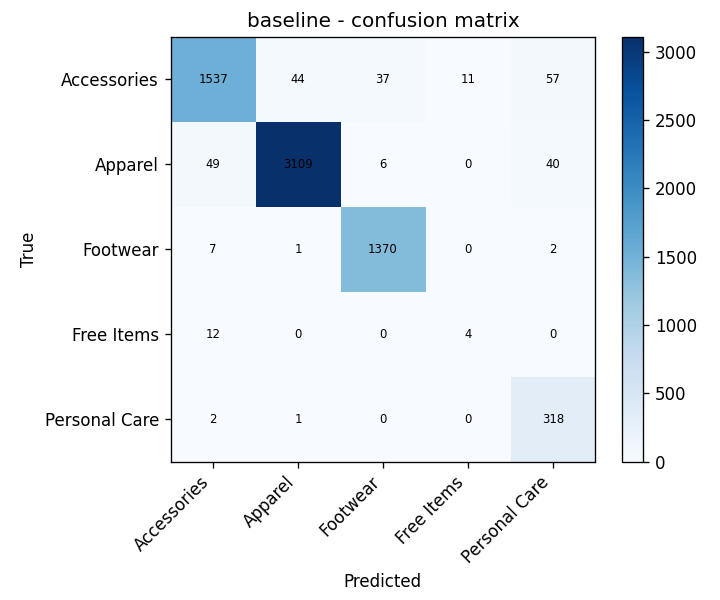

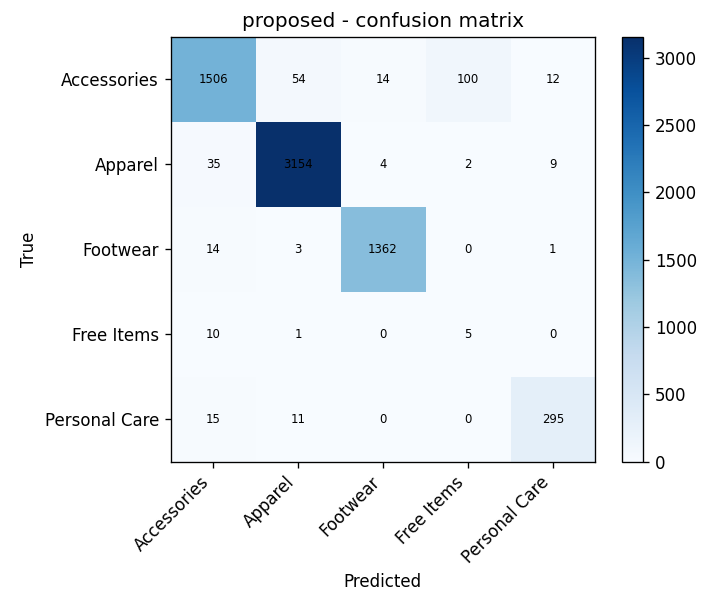

In [5]:
display(Image(filename=str(ARTIFACTS / "confusion_matrix_baseline.png")))
display(Image(filename=str(ARTIFACTS / "confusion_matrix_proposed.png")))

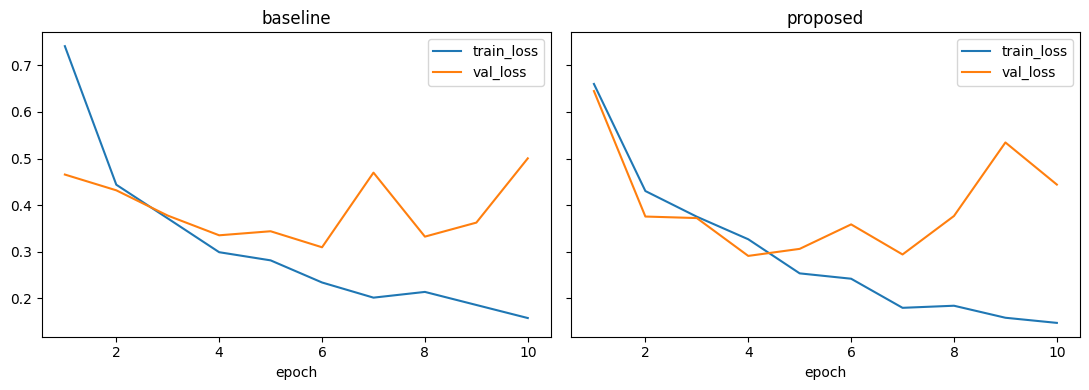

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, name in zip(axes, ("baseline", "proposed")):
    hist = pd.DataFrame(metrics[name]["training_history"]).set_index("epoch")
    ax.plot(hist.index, hist["train_loss"], label="train_loss")
    ax.plot(hist.index, hist["val_loss"], label="val_loss")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()

## Operational framing: the auto-tag rate

Accuracy is a model metric. The question a catalog team actually cares about is: *for what share of incoming products can we trust the model's tag without a human reviewing it?* We treat "confidence >= 0.85" as that bar (configurable -- the Streamlit app's Quality Monitoring page lets you slide it).

In [7]:
import numpy as np

rows = []
for name in ("baseline", "proposed"):
    labels = np.array(metrics[name]["test_labels"])
    confs = np.array(metrics[name]["test_confidences"])
    for i, c in enumerate(class_names):
        mask = labels == i
        rows.append({
            "model": name, "category": c,
            "auto_tag_rate": (confs[mask] >= 0.85).mean() if mask.sum() else float("nan"),
            "support": int(mask.sum()),
        })
pd.DataFrame(rows).pivot(index="category", columns="model", values="auto_tag_rate").round(3)

model,baseline,proposed
category,,
Accessories,0.848,0.770
Apparel,0.939,0.967
Footwear,0.988,0.977
Free Items,0.750,0.625
Personal Care,0.938,0.816


## The agent layer

On top of the classifier, a small local agent (Ollama, `llama3.1:8b` -- no external API) has two tools: `classify_product` (calls the trained model above) and `search_similar_products` (RAG over the catalog's text metadata via Chroma). The agent decides on its own which tool a question needs.

In [8]:
from src.agent import chat

result = chat("Do you have any blue casual shoes for men?")
print("Tool calls made:", [t["tool"] for t in result["tool_trace"]])
print()
print(result["reply"])

C:\Users\vitor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import issparse


Tool calls made: ['search_similar_products']

We have a variety of blue casual shoes for men that you might like:

* ID Men Blue Casual Shoes
* Nike Men Blue Flyclave LTR Casual Shoes
* Clarks Men Navy Blue Casual Shoes
* Reebok Men Navy Blue Varsity Casual Shoes

Please let me know if you'd like more information or to purchase any of these items.


## Limitations & next steps

- **`subCategory` / `articleType` as a harder follow-on target.** `masterCategory` was the right scope for a clean v0 story, but the gender signal almost certainly matters more at finer granularity (e.g. specific article types skew much more by gender than broad categories do).
- **Two-head multi-task output** (predict masterCategory *and* subCategory together) is a natural v1.5 -- deliberately scoped out here to keep the comparison clean.
- **Free Items stays unreliable** for any model trained on this dataset as-is; it would need targeted data collection, not a better architecture.
- **Checkpoint hosting:** the Live Demo currently requires running `src/train.py` locally first. Hosting checkpoints on a GitHub Release or the HF Hub would make the demo work on a fresh clone with zero setup.
- **Confidence calibration:** the 0.85 auto-tag threshold is a reasonable starting point, not a calibrated one -- a calibration pass (e.g. temperature scaling) would make the operational numbers more trustworthy.